# RNN for Sentiment Analysis (IMDB Dataset)

In [21]:
import os
import pandas as pd
import re
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [22]:
csv_path=None
for root,dirs,files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and 'IMDB' in f:
            csv_path=os.path.join(root,f)

print('Using:',csv_path)
df=pd.read_csv(csv_path)
df.head()

Using: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [23]:
def tokenize(text):
    text=text.lower()
    text=re.sub(r'<.*?>','',text)
    text=re.sub(r'[^a-z\s]','',text)
    return text.split()

texts=df['review'].tolist()
labels=df['sentiment'].apply(lambda x:1 if x=='positive' else 0).tolist()

tokens=[tokenize(t) for t in texts]

In [24]:
counter=Counter()
for t in tokens:
    counter.update(t)

vocab={w:i+2 for i,(w,_) in enumerate(counter.most_common(20000))}
vocab['<pad>']=0
vocab['<unk>']=1

vocab_size=len(vocab)
print(vocab_size)

20002


In [25]:
def encode(t):
    return [vocab.get(w,1) for w in t]

In [26]:
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self,texts,labels):
        self.texts=texts
        self.labels=labels
    def __len__(self): return len(self.texts)
    def __getitem__(self,idx):
        return torch.tensor(encode(self.texts[idx])), torch.tensor(self.labels[idx])

In [27]:
def collate_fn(batch):
    texts,labels=zip(*batch)
    max_len=200
    padded=[]
    for t in texts:
        if len(t)<max_len:
            t=torch.cat([t,torch.zeros(max_len-len(t))])
        else:
            t=t[:max_len]
        padded.append(t)
    return torch.stack(padded).long(), torch.tensor(labels)

In [28]:
train_texts=tokens[:40000]
train_labels=labels[:40000]

test_texts=tokens[40000:]
test_labels=labels[40000:]

In [29]:
train_loader=DataLoader(IMDBDataset(train_texts,train_labels),batch_size=64,shuffle=True,collate_fn=collate_fn)
test_loader=DataLoader(IMDBDataset(test_texts,test_labels),batch_size=64,collate_fn=collate_fn)

In [30]:
class RNNModel(nn.Module):
    def __init__(self,vocab_size,embed_dim,hidden_dim):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,embed_dim)
        self.rnn=nn.RNN(embed_dim,hidden_dim,batch_first=True)
        self.fc=nn.Linear(hidden_dim,2)
    def forward(self,x):
        x=self.embedding(x)
        out,_=self.rnn(x)
        out=out[:,-1,:]
        return self.fc(out)

In [31]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=RNNModel(vocab_size,100,128).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()

In [32]:
train_acc_list=[]
val_acc_list=[]

def train():
    model.train()
    correct=total=0
    for x,y in train_loader:
        x,y=x.to(device),y.to(device)
        optimizer.zero_grad()
        out=model(x)
        loss=criterion(out,y)
        loss.backward()
        optimizer.step()
        pred=out.argmax(1)
        correct+=(pred==y).sum().item()
        total+=y.size(0)
    return correct/total

def evaluate():
    model.eval()
    correct=total=0
    preds_all=[]
    labels_all=[]
    with torch.no_grad():
        for x,y in test_loader:
            x,y=x.to(device),y.to(device)
            out=model(x)
            pred=out.argmax(1)
            preds_all.extend(pred.cpu())
            labels_all.extend(y.cpu())
            correct+=(pred==y).sum().item()
            total+=y.size(0)
    return correct/total,preds_all,labels_all

In [39]:
for epoch in range(50):
    train_acc=train()
    val_acc,preds,labels=evaluate()
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    print(epoch+1,train_acc,val_acc)

1 0.68435 0.5234
2 0.688375 0.524
3 0.6821 0.5298
4 0.692925 0.5282
5 0.70125 0.5389
6 0.70375 0.5315
7 0.70105 0.5268
8 0.70215 0.5308
9 0.702075 0.5365
10 0.7074 0.5389
11 0.702675 0.5241
12 0.69095 0.5369
13 0.7036 0.5361
14 0.7069 0.5338
15 0.701025 0.5301
16 0.705725 0.5394
17 0.69985 0.5294
18 0.69965 0.5298
19 0.70465 0.5367
20 0.707425 0.5347
21 0.706175 0.5354
22 0.6962 0.5244
23 0.70365 0.5342
24 0.705975 0.5354
25 0.70395 0.5361
26 0.71245 0.5371
27 0.711175 0.5315
28 0.707975 0.5227
29 0.706 0.5399
30 0.7082 0.5336
31 0.7093 0.5391
32 0.711525 0.5383
33 0.705325 0.5362
34 0.708675 0.5301
35 0.713225 0.5336
36 0.653025 0.5219
37 0.6578 0.5197
38 0.647275 0.5222
39 0.66085 0.5257
40 0.67485 0.5245
41 0.682925 0.5298
42 0.6886 0.5298
43 0.69125 0.5299
44 0.689275 0.5299
45 0.662575 0.5258
46 0.658825 0.5251
47 0.671025 0.5351
48 0.67765 0.5335
49 0.6877 0.5352
50 0.6931 0.5364


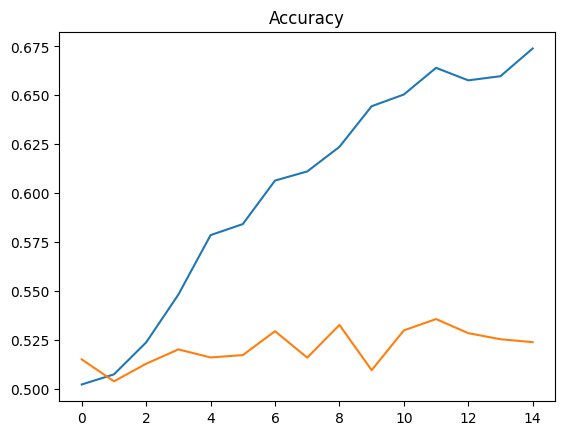

In [37]:
plt.figure()
plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.title('Accuracy')
plt.show()

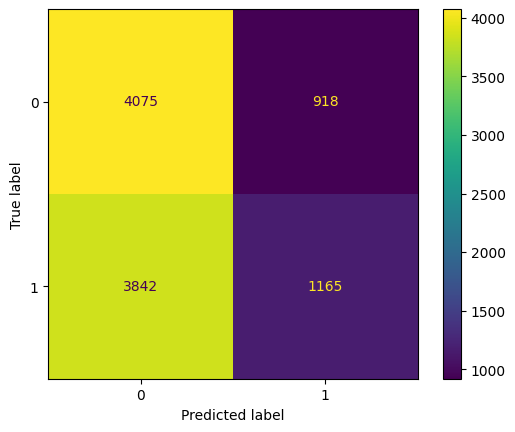

In [38]:
cm=confusion_matrix(labels,preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()